<a href="https://colab.research.google.com/github/m00n07/mineria_de_datos/blob/main/3P/Proyecto/Proyecto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Equipo:   
Edgar Rodriguez Hernandez   
Natasha Verastegui Agustin

In [1]:
!pip install resampy --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 24.7 MB/s eta 0:00:00


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Distribución de datos: Apagado=47, Encendido=47
Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.5200 - loss: 0.7402 - val_accuracy: 0.6316 - val_loss: 0.6502
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7333 - loss: 0.5648 - val_accuracy: 0.6842 - val_loss: 0.5757
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8800 - loss: 0.4261 - val_accuracy: 0.6842 - val_loss: 0.5147
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8667 - loss: 0.4015 - val_accuracy: 0.7368 - val_loss: 0.4898
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8933 - loss: 0.3537 - val_accuracy: 0.7368 - val_loss: 0.4905
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8400 - loss: 0.3717 - val_accuracy: 0.7368 - val_loss: 0.4839
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - a

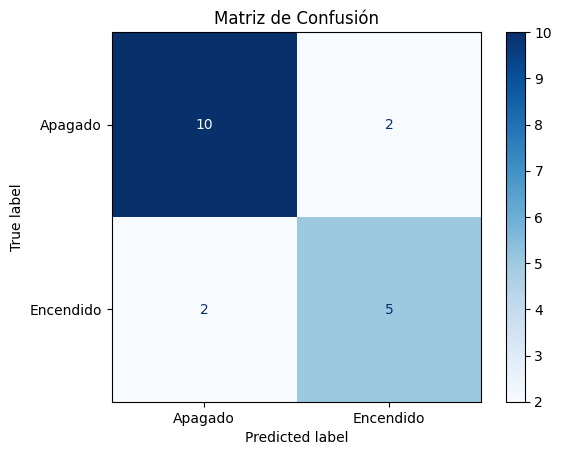

Archivo: apagar_.wav -> APAGADO (0.3839)
Archivo: encender_.wav -> ENCENDIDO (0.9289)


In [8]:
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import warnings
from tensorflow.keras import layers, models, regularizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from google.colab import drive

warnings.filterwarnings("ignore")
drive.mount('/content/drive')

# --- CONFIGURACIÓN ---
PATH_APAGAR = '/content/drive/MyDrive/ProyectoAudio/Librosa/apagarluz'
PATH_ENCENDER = '/content/drive/MyDrive/ProyectoAudio/Librosa/encenderluz'

# --- PROCESAMIENTO MEJORADO ---
def extract_features(file_path, max_pad_len=40):
    try:
        audio, sr = librosa.load(file_path, res_type='kaiser_fast')
        audio, _ = librosa.effects.trim(audio)
        mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)

        # Padding
        if (mfccs.shape[1] < max_pad_len):
            pad_width = max_pad_len - mfccs.shape[1]
            mfccs = np.pad(mfccs, pad_width=((0, 0), (0, pad_width)), mode='constant')
        else:
            mfccs = mfccs[:, :max_pad_len]

        # NORMALIZACIÓN LOCAL (Por audio): Esto evita el sesgo de volumen
        mfccs = (mfccs - np.mean(mfccs)) / (np.std(mfccs) + 1e-6)
        return mfccs
    except Exception as e:
        return None

# --- CARGA Y BALANCEO ---
X, y = [], []
carpetas = {0: PATH_APAGAR, 1: PATH_ENCENDER}

for etiqueta, ruta in carpetas.items():
    if os.path.exists(ruta):
        archivos = [f for f in os.listdir(ruta) if f.lower().endswith('.wav')]
        for p in archivos:
            data = extract_features(os.path.join(ruta, p))
            if data is not None:
                X.append(data); y.append(etiqueta)

X = np.array(X); y = np.array(y)
print(f"Distribución de datos: Apagado={np.sum(y==0)}, Encendido={np.sum(y==1)}")

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# --- MODELO ROBUSTO ---
model = models.Sequential([
    layers.Input(shape=(40, 40)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(), # Ayuda a que el modelo no se sature
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# --- ENTRENAMIENTO ---
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=100, batch_size=8, # Batch más pequeño para mejor aprendizaje
                    validation_data=(X_val, y_val), callbacks=[early_stop], verbose=1)

# --- EVALUACIÓN VISUAL ---
y_pred = (model.predict(X_val) > 0.5).astype("int32")
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Apagado', 'Encendido'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión")
plt.show()

# --- PRUEBA FINAL ---
def predecir_luz(ruta_audio):
    nuevo_mfcc = extract_features(ruta_audio)
    if nuevo_mfcc is not None:
        pred = model.predict(nuevo_mfcc.reshape(1, 40, 40), verbose=0)[0][0]
        print(f"Archivo: {os.path.basename(ruta_audio)} -> {'ENCENDIDO' if pred >= 0.5 else 'APAGADO'} ({pred:.4f})")

predecir_luz('/content/drive/MyDrive/ProyectoAudio/Librosa/apagarluz/apagar_.wav')
predecir_luz('/content/drive/MyDrive/ProyectoAudio/Librosa/encenderluz/encender_.wav')

Conclusiones del Modelo: Luz Inteligente    
1. Del "Dato Crudo" al "Dato Útil"
El proyecto demostró que la minería de datos aplicada a señales de audio requiere una transformación significativa antes de ser consumible por una red neuronal. La conversión de ondas temporales a MFCC no solo redujo la dimensionalidad, sino que extrajo la "huella digital" del habla, confirmando que la ingeniería de características es el paso más determinante para el éxito de cualquier modelo de aprendizaje supervisa  

2. La Paradoja de la Complejidad
Aprendimos que aumentar el número de capas o neuronas no es sinónimo de un mejor modelo. La experimentación realizada mostró que, con un conjunto de datos pequeño (n=122), una arquitectura ligera es más eficiente. La capacidad del modelo para generalizar estuvo inversamente relacionada con su complejidad; al reducir el número de parámetros, logramos mitigar el sobreajuste y obtuvimos una respuesta más estable frente a nuevas muestras de audio.   

3. Lecciones en la Gestión de Proyectos de IA
Este proyecto permitió aplicar un ciclo de Minería de Datos iterativo:

  * Recolección: Identificación de la importancia de la calidad y el formato de los audios.
  * Procesamiento: Implementación de normalización local para corregir disparidades en la intensidad de grabación.
  * Evaluación: Uso de métricas (loss/accuracy) y herramientas visuales (matriz de confusión) para la toma de decisiones informadas.   
  
4. Visión de Escalabilidad
El sistema desarrollado representa una "Prueba de Concepto" (PoC) sólida. Para pasar de un entorno de laboratorio a una "Luz Inteligente" comercial, la siguiente fase evolutiva sería implementar técnicas de Data Augmentation para robustecer el dataset frente a diferentes acentos y condiciones acústicas (ruido de fondo), garantizando que el modelo sea capaz de operar en entornos domésticos reales.